In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

I0000 00:00:1774461742.476702 2900438 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
from tensorflow.keras.applications.efficientnet import preprocess_input
import os
import cv2
import numpy as np
from tqdm import tqdm

home = os.path.expanduser("~")
dataset_path = os.path.join(home, "hybrid_tumor_project", "extracted_data", "Figshare dataset")
IMG_SIZE = 224

images = []
labels = []

for label, folder in enumerate(sorted(os.listdir(dataset_path))):
    folder_path = os.path.join(dataset_path, folder)

    for file in tqdm(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, file)

        img = cv2.imread(img_path)

        if img is not None:
            # 🔥 FIX 1: Convert BGR → RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Resize
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # Preprocess for EfficientNet
            img = preprocess_input(img)

            images.append(img)
            labels.append(label)

X = np.array(images, dtype=np.float32)
y = np.array(labels)

print("DATA SHAPE:", X.shape)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 930/930 [00:02<00:00, 460.24it/s]


DATA SHAPE: (3064, 224, 224, 3)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [5]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.7160385626643295), 1: np.float64(1.4434628975265018), 2: np.float64(1.0981182795698925)}


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_gen = datagen.flow(X_train, y_train, batch_size=8)

In [7]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [8]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze top layers
for layer in base_model.layers[-50:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.00005)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

E0000 00:00:1774461762.105780 2900438 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1774461762.105935 2900438 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
I0000 00:00:1774461762.105957 2900438 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
I0000 00:00:1774461762.105984 2900438 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1774461762.105991 2900438 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: srmap
I0000 00:00:1774461762.105998 2900438 cuda_diagnostics.cc:183] hostname: srmap
I0000 00:00:1774461762.106184 2900438 cuda_diagnostics.cc:190] libcuda reported version is: 555.42.2
I0000 00:00:1774461762.106220 2900438 cuda_diagnostics.cc:194] kernel reported ve

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 2,691,219 (10.27 MB)

 Non-trainable params: 1,522,707 (5.81 MB)

In [9]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 73s 346ms/step - accuracy: 0.6373 - loss: 0.8015 - val_accuracy: 0.8336 - val_loss: 0.4694 - learning_rate: 5.0000e-05
Epoch 2/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 49s 318ms/step - accuracy: 0.8339 - loss: 0.4438 - val_accuracy: 0.8874 - val_loss: 0.3045 - learning_rate: 5.0000e-05
Epoch 3/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 51s 331ms/step - accuracy: 0.8747 - loss: 0.3158 - val_accuracy: 0.9038 - val_loss: 0.2470 - learning_rate: 5.0000e-05
Epoch 4/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 54s 351ms/step - accuracy: 0.9086 - loss: 0.2494 - val_accuracy: 0.9250 - val_loss: 0.2068 - learning_rate: 5.0000e-05
Epoch 5/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 58s 378ms/step - accuracy: 0.9131 - loss: 0.2190 - val_accuracy: 0.9217 - val_loss: 0.1954 - learning_rate: 5.0000e-05
Epoch 6/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 59s 385ms/step - accuracy: 0.9270 - loss: 0.1826 - val_accuracy: 0.9445 - val_loss: 0.1603 - learning_rate: 5.0000e-05
Epoch 7/40
154/154 ━━━━━━━━━━━━━━━━━━━━ 58s 37

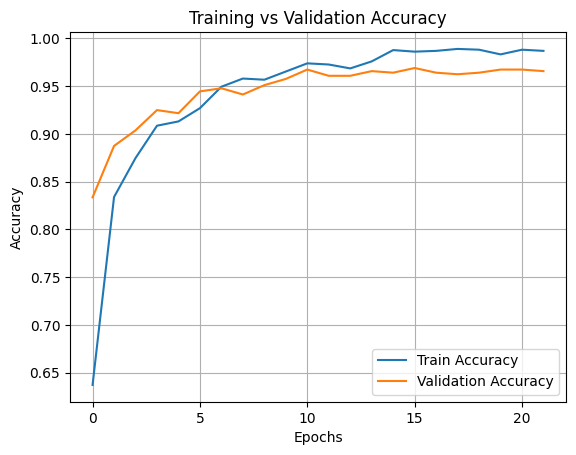

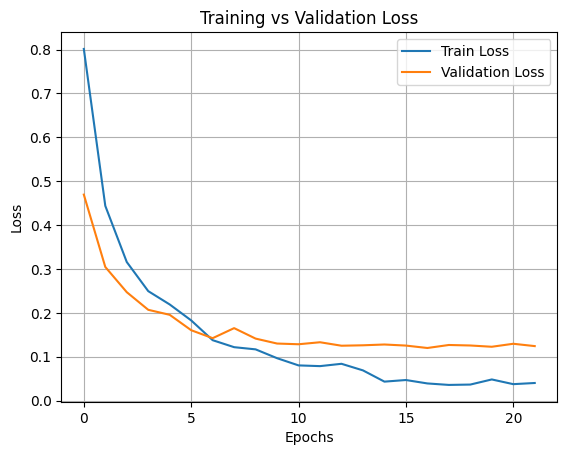

In [10]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

# Loss Graph
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 393ms/step


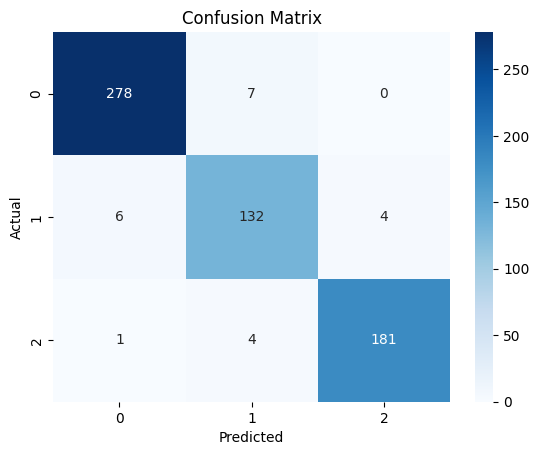

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       285
           1       0.92      0.93      0.93       142
           2       0.98      0.97      0.98       186

    accuracy                           0.96       613
   macro avg       0.96      0.96      0.96       613
weighted avg       0.96      0.96      0.96       613



In [13]:
model.save("brain_tumor_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


Predicted: Glioma
[[9.9601549e-01 3.9087045e-03 7.5768803e-05]]


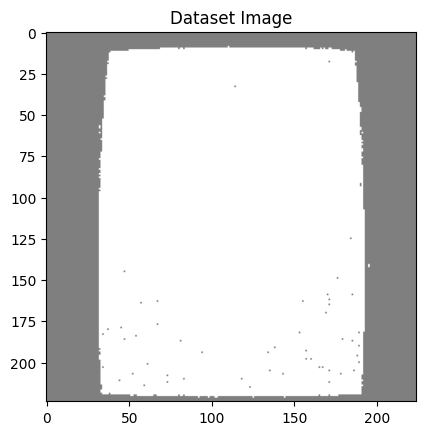

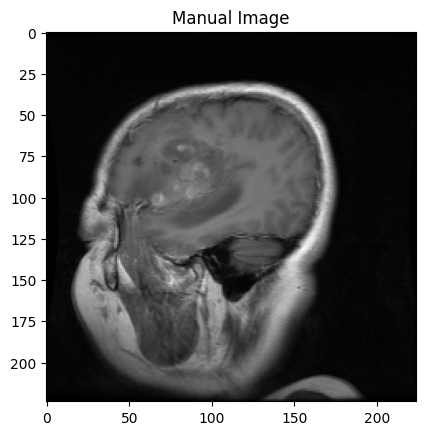

Train image range: 0.0 241.0
Manual image range: 0 252


In [14]:
import cv2
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input

# Path to test image
img_path = os.path.join(home,"hybrid_tumor_project", "866.jpg")

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  #  SAME FIX
img = cv2.resize(img, (224, 224))
img = preprocess_input(img)
img = np.expand_dims(img, axis=0)

# Predict
prediction = model.predict(img)
class_id = np.argmax(prediction)

# Correct class mapping
classes = ["Glioma", "Meningioma", "Pituitary"]

print("Predicted:", classes[class_id])
print(prediction)

import matplotlib.pyplot as plt

# Dataset image
plt.imshow((X_test[0] + 1)/2)  # reverse preprocess for display
plt.title("Dataset Image")
plt.show()

# Your test image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224,224))
plt.imshow(img)
plt.title("Manual Image")
plt.show()

print("Train image range:", X_train[0].min(), X_train[0].max())
print("Manual image range:", img.min(), img.max())

Grad-Cam

In [15]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [16]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap

In [17]:
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224,224))

img_array = np.expand_dims(img, axis=0)
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

heatmap = get_gradcam_heatmap(model, img_array, "top_conv")

/home/dgxuser45/.local/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


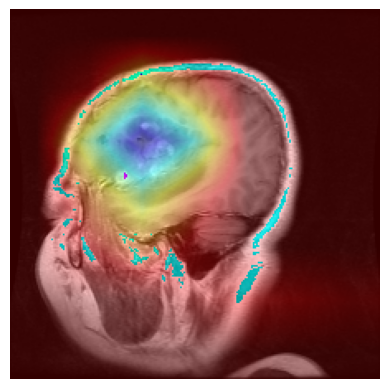

In [18]:
heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.imshow(superimposed_img.astype("uint8"))
plt.axis("off")
plt.show()